# 03 — Modélisation du modèle 1 principal

Ce notebook formalise la sélection du **modèle 1** utilisé dans l’application.

## Objectifs
- comparer rapidement plusieurs familles de modèles sur un **échantillon léger** ;
- comparer plusieurs variantes **crop-aware** cohérentes avec l’usage métier ;
- conserver une **baseline générale** comme référence interne ;
- retenir et exporter le **modèle principal final** utilisé par l’API.

## Entrées
- `crop_aux_clean.csv`
- `crop_aux_enriched.csv`

## Sorties
- `artifacts/model_1_general.joblib`
- `artifacts/model_1_general_meta.json`
- `artifacts/model_1_crop.joblib`
- `artifacts/model_1_crop_meta.json`

## Positionnement dans la démarche
Les étapes d’exploration et de feature engineering sont réalisées dans les notebooks précédents.  
Le présent notebook se concentre sur la **comparaison de modèles**, la **sélection finale** et la **formalisation des artefacts déployés**.

In [1]:
from pathlib import Path
import sys
import json
import joblib

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

from project_paths import PROCESSED_DIR

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

SEED = 42
SAMPLE_SIZE = 120_000

ARTIFACTS_DIR = ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)

ROOT: C:\Users\thoma\Documents\Openclassroom\Projet-12
PROCESSED_DIR: C:\Users\thoma\Documents\Openclassroom\Projet-12\data\processed
ARTIFACTS_DIR: C:\Users\thoma\Documents\Openclassroom\Projet-12\artifacts


In [2]:
MLFLOW_DB_PATH = ROOT / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH.as_posix()}")
mlflow.set_experiment("projet-12-model-1-v2")

print("MLflow version:", mlflow.__version__)
print("Tracking URI:", mlflow.get_tracking_uri())

2026/04/01 00:17:56 INFO mlflow.tracking.fluent: Experiment with name 'projet-12-model-1-v2' does not exist. Creating a new experiment.


MLflow version: 3.10.1
Tracking URI: sqlite:///C:/Users/thoma/Documents/Openclassroom/Projet-12/mlflow.db


## 1. Chargement des données

Deux jeux sont mobilisés :

- `crop_aux_clean.csv` pour la **baseline générale** ;
- `crop_aux_enriched.csv` pour les variantes tenant compte de la culture et des profils externes.

La cible est supposée avoir déjà été nettoyée dans le notebook d’analyse exploratoire.

In [3]:
crop_aux = pd.read_csv(PROCESSED_DIR / "crop_aux_clean.csv")
crop_aux_enriched = pd.read_csv(PROCESSED_DIR / "crop_aux_enriched.csv")

target_col = "Yield_tons_per_hectare"

print("crop_aux shape:", crop_aux.shape)
print("crop_aux_enriched shape:", crop_aux_enriched.shape)

assert target_col in crop_aux.columns, f"{target_col} absent de crop_aux."
assert target_col in crop_aux_enriched.columns, f"{target_col} absent de crop_aux_enriched."
assert (crop_aux[target_col] >= 0).all(), "La cible de crop_aux contient encore des valeurs négatives."
assert (crop_aux_enriched[target_col] >= 0).all(), "La cible de crop_aux_enriched contient encore des valeurs négatives."

display(crop_aux[[target_col]].describe().T)

crop_aux shape: (999769, 10)
crop_aux_enriched shape: (999769, 19)


,count,mean,std,min,25%,50%,75%,max
Yield_tons_per_hectare,999769.0,4.650592,1.695166,0.000411,3.418669,4.652333,5.879576,9.963372


In [4]:
crop_aux_sample = crop_aux.sample(
    n=min(SAMPLE_SIZE, len(crop_aux)),
    random_state=SEED,
).copy()

crop_aux_enriched_sample = crop_aux_enriched.sample(
    n=min(SAMPLE_SIZE, len(crop_aux_enriched)),
    random_state=SEED,
).copy()

print("Sample clean:", crop_aux_sample.shape)
print("Sample enriched:", crop_aux_enriched_sample.shape)

Sample clean: (120000, 10)
Sample enriched: (120000, 19)


## 2. Fonctions utilitaires

Les fonctions suivantes standardisent :
- le préprocessing ;
- l’évaluation ;
- la validation croisée ;
- l’export des artefacts.

L’objectif est de garder un notebook lisible et reproductible.

In [5]:
def split_feature_types(df: pd.DataFrame):
    bool_features = df.select_dtypes(include="bool").columns.tolist()
    numeric_features = df.select_dtypes(include=np.number).columns.tolist()
    numeric_features = numeric_features + [c for c in bool_features if c not in numeric_features]
    categorical_features = [c for c in df.columns if c not in numeric_features]
    return numeric_features, categorical_features


def build_preprocessor(numeric_features, categorical_features):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ])


def evaluate_regression(y_true, y_pred, dataset_name: str, model_name: str) -> dict:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {
        "dataset": dataset_name,
        "model": model_name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }


def make_pipeline(model, X: pd.DataFrame):
    numeric_features, categorical_features = split_feature_types(X)
    preprocessor = build_preprocessor(numeric_features, categorical_features)
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])


def make_interaction_pipeline(model, X: pd.DataFrame):
    numeric_features, categorical_features = split_feature_types(X)
    preprocessor = build_preprocessor(numeric_features, categorical_features)
    return Pipeline([
        ("preprocessor", preprocessor),
        ("interactions", PolynomialFeatures(
            degree=2,
            interaction_only=True,
            include_bias=False,
        )),
        ("model", model),
    ])


def benchmark_models(X_train, X_test, y_train, y_test, models: dict, dataset_name: str, stage: str):
    results = []

    for model_name, model in models.items():
        pipe = make_pipeline(model, X_train)

        with mlflow.start_run(run_name=f"{dataset_name}__{model_name}"):
            mlflow.set_tags({
                "project": "Projet-12",
                "notebook": "03_modeling_baseline_cleaned",
                "stage": stage,
                "dataset_name": dataset_name,
                "model_name": model_name,
            })
            mlflow.log_param("dataset_name", dataset_name)
            mlflow.log_param("model_name", model_name)
            mlflow.log_param("stage", stage)
            mlflow.log_param("n_train_rows", len(X_train))
            mlflow.log_param("n_test_rows", len(X_test))
            mlflow.log_param("feature_names", ",".join(X_train.columns.tolist()))

            if hasattr(model, "get_params"):
                safe_params = {}
                for k, v in model.get_params().items():
                    if isinstance(v, (str, int, float, bool, np.integer, np.floating)):
                        safe_params[k] = v
                if safe_params:
                    mlflow.log_params(safe_params)

            pipe.fit(X_train, y_train)
            preds = pipe.predict(X_test)
            result = evaluate_regression(y_test, preds, dataset_name, model_name)

            mlflow.log_metrics({
                "rmse": result["rmse"],
                "mae": result["mae"],
                "r2": result["r2"],
            })

            results.append(result)

    return pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)


def cross_validate_pipeline(pipe, X, y, run_name: str, stage: str, extra_params: dict | None = None):
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2",
    }

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    summary = {
        "rmse_mean": float(-scores["test_rmse"].mean()),
        "rmse_std": float((-scores["test_rmse"]).std()),
        "mae_mean": float(-scores["test_mae"].mean()),
        "mae_std": float((-scores["test_mae"]).std()),
        "r2_mean": float(scores["test_r2"].mean()),
        "r2_std": float(scores["test_r2"].std()),
    }

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags({
            "project": "Projet-12",
            "notebook": "03_modeling_baseline_cleaned",
            "stage": stage,
        })
        if extra_params:
            mlflow.log_params(extra_params)
        mlflow.log_metrics(summary)

    return summary


def holdout_metrics(pipe, X_train, X_test, y_train, y_test, dataset_name: str, model_name: str):
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    return evaluate_regression(y_test, preds, dataset_name, model_name), preds


def export_model_with_meta(pipe, X_ref, y_ref, meta: dict, model_path: Path, meta_path: Path, run_name: str):
    pipe.fit(X_ref, y_ref)
    signature = infer_signature(X_ref, pipe.predict(X_ref.head(min(100, len(X_ref)))))

    joblib.dump(pipe, model_path)

    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags({
            "project": "Projet-12",
            "notebook": "03_modeling_baseline_cleaned",
            "stage": "export_model",
            "export_name": model_path.name,
        })

        params_to_log = {}
        for k, v in meta.items():
            if isinstance(v, (str, int, float, bool)):
                params_to_log[k] = v
        if params_to_log:
            mlflow.log_params(params_to_log)

        if "reference_metrics" in meta:
            for k, v in meta["reference_metrics"].items():
                if isinstance(v, (int, float)):
                    mlflow.log_metric(k, float(v))

        mlflow.sklearn.log_model(
            sk_model=pipe,
            artifact_path="model",
            signature=signature,
        )
        mlflow.log_artifact(str(meta_path))

## 3. Benchmark léger sur échantillon

Cette étape remplit deux fonctions :
- disposer d’un benchmark rapide et reproductible sur un volume limité ;
- sélectionner un petit nombre de variantes crédibles avant la validation complète.

L’échantillon n’a pas vocation à remplacer la validation finale sur le dataset complet.

### 3.1 Baseline générale sur échantillon

Cette première comparaison utilise uniquement le contexte général :
- pluie ;
- température ;
- usage d’engrais ;
- irrigation.

Elle permet de conserver une référence simple et stable.

In [6]:
general_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
]

X_general_sample = crop_aux_sample[general_features].copy()
y_general_sample = crop_aux_sample[target_col].copy()

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_general_sample,
    y_general_sample,
    test_size=0.2,
    random_state=SEED,
)

general_models = {
    "dummy_mean": DummyRegressor(strategy="mean"),
    "ridge_alpha_0.1": Ridge(alpha=0.1),
    "catboost_small": CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_state=SEED,
        verbose=0,
        allow_writing_files=False,
        thread_count=1,
    ),
    "xgboost_small": XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=1,
    ),
}

general_sample_results = benchmark_models(
    X_train=Xg_train,
    X_test=Xg_test,
    y_train=yg_train,
    y_test=yg_test,
    models=general_models,
    dataset_name="sample_general",
    stage="general_sample_benchmark",
)
display(general_sample_results)

,dataset,model,rmse,mae,r2
0,sample_general,ridge_alpha_0.1,0.497640,0.396661,0.913306
1,sample_general,catboost_small,0.498298,0.397288,0.913077
2,sample_general,xgboost_small,0.500619,0.399089,0.912265
3,sample_general,dummy_mean,1.690141,1.384472,-0.000003


### 3.2 Variantes crop-aware sur échantillon

Plusieurs versions tenant compte de la culture sont comparées :

- **crop_base** : culture + variables de contexte ;
- **crop_enriched** : ajout des variables de profil externe ;
- **crop_enriched_pca** : ajout des composantes ACP de profil ;
- **crop_enriched_interactions** : ajout d’interactions de second ordre, sans termes quadratiques.

Cette étape permet d’évaluer si l’enrichissement et les interactions apportent un gain utile.

In [7]:
crop_base_features = [
    "Crop",
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
]

crop_enriched_features = [
    "Crop",
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "ext_mean_temp_by_crop",
    "ext_mean_rainfall_by_crop",
    "ext_mean_pesticides_by_crop",
    "ext_n_obs_by_crop",
    "rainfall_gap_vs_crop_profile",
    "temp_gap_vs_crop_profile",
]

crop_enriched_pca_features = [
    *crop_enriched_features,
    "crop_profile_pc1",
    "crop_profile_pc2",
]

sample_df = crop_aux_enriched_sample.copy()
y_crop_sample = sample_df[target_col].copy()

X_crop_base_sample = sample_df[crop_base_features].copy()
X_crop_enriched_sample = sample_df[crop_enriched_features].copy()
X_crop_enriched_pca_sample = sample_df[crop_enriched_pca_features].copy()

Xcb_train, Xcb_test, ycb_train, ycb_test = train_test_split(
    X_crop_base_sample, y_crop_sample, test_size=0.2, random_state=SEED
)
Xce_train, Xce_test, yce_train, yce_test = train_test_split(
    X_crop_enriched_sample, y_crop_sample, test_size=0.2, random_state=SEED
)
Xcep_train, Xcep_test, ycep_train, ycep_test = train_test_split(
    X_crop_enriched_pca_sample, y_crop_sample, test_size=0.2, random_state=SEED
)

sample_crop_variants = []

for variant_name, X_train, X_test, y_train, y_test in [
    ("crop_base", Xcb_train, Xcb_test, ycb_train, ycb_test),
    ("crop_enriched", Xce_train, Xce_test, yce_train, yce_test),
    ("crop_enriched_pca", Xcep_train, Xcep_test, ycep_train, ycep_test),
]:
    pipe = make_pipeline(Ridge(alpha=0.1), X_train)
    result, _ = holdout_metrics(
        pipe,
        X_train,
        X_test,
        y_train,
        y_test,
        dataset_name=variant_name,
        model_name="ridge_alpha_0.1",
    )
    sample_crop_variants.append(result)

sample_crop_variants_df = (
    pd.DataFrame(sample_crop_variants)
    .sort_values("rmse")
    .reset_index(drop=True)
)

display(sample_crop_variants_df)

,dataset,model,rmse,mae,r2
0,crop_enriched,ridge_alpha_0.1,0.497603,0.396633,0.913320
1,crop_enriched_pca,ridge_alpha_0.1,0.497603,0.396633,0.913320
2,crop_base,ridge_alpha_0.1,0.497632,0.396643,0.913309


### 3.3 Candidats avancés sur échantillon

Un contrôle complémentaire est réalisé sur deux familles de candidats :

- **CatBoost** sur la variante enrichie, pour tester un candidat non linéaire ;
- **Ridge avec interactions** sur la variante enrichie, pour mesurer le gain apporté par les interactions explicites.

L’objectif n’est pas de multiplier les benchmarks, mais de challenger la meilleure piste linéaire.

In [8]:
catboost_crop_enriched_sample = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_state=SEED,
    verbose=0,
    allow_writing_files=False,
    thread_count=1,
)

catboost_crop_pipe = make_pipeline(catboost_crop_enriched_sample, Xce_train)
catboost_crop_result, _ = holdout_metrics(
    catboost_crop_pipe,
    Xce_train,
    Xce_test,
    yce_train,
    yce_test,
    dataset_name="crop_enriched",
    model_name="catboost_enriched",
)

interaction_alphas = [0.1, 1.0, 10.0]
sample_interaction_results = []

for alpha in interaction_alphas:
    pipe = make_interaction_pipeline(Ridge(alpha=alpha), Xce_train)
    result, _ = holdout_metrics(
        pipe,
        Xce_train,
        Xce_test,
        yce_train,
        yce_test,
        dataset_name="crop_enriched_interactions",
        model_name=f"ridge_interactions_alpha_{alpha}",
    )
    result["alpha"] = alpha
    sample_interaction_results.append(result)

sample_interaction_results_df = (
    pd.DataFrame(sample_interaction_results)
    .sort_values("rmse")
    .reset_index(drop=True)
)

display(pd.DataFrame([catboost_crop_result]))
display(sample_interaction_results_df)

,dataset,model,rmse,mae,r2
0,crop_enriched,catboost_enriched,0.498178,0.397251,0.913119


,dataset,model,rmse,mae,r2,alpha
0,crop_enriched_interactions,ridge_interactions_alpha_0.1,0.497752,0.396796,0.913268,0.1
1,crop_enriched_interactions,ridge_interactions_alpha_1.0,0.497752,0.396796,0.913268,1.0
2,crop_enriched_interactions,ridge_interactions_alpha_10.0,0.497753,0.396796,0.913267,10.0


### 3.4 Synthèse du benchmark léger

Les résultats précédents permettent d’identifier les variantes à conserver pour la validation complète.
La suite du notebook se limite volontairement à un nombre restreint de candidats afin de préserver la lisibilité du support.

In [9]:
sample_summary = pd.concat(
    [
        general_sample_results.assign(block="general_sample"),
        sample_crop_variants_df.assign(block="crop_variant_sample"),
        pd.DataFrame([catboost_crop_result]).assign(block="crop_model_family_sample"),
        sample_interaction_results_df.assign(block="crop_interactions_sample"),
    ],
    ignore_index=True,
    sort=False,
)

display(sample_summary.sort_values(["block", "rmse"]).reset_index(drop=True))
best_interaction_alpha = float(sample_interaction_results_df.loc[0, "alpha"])
print("Alpha retenu pour la variante interactions :", best_interaction_alpha)

,dataset,model,rmse,mae,r2,block,alpha
0,crop_enriched_interactions,ridge_interactions_alpha_0.1,0.497752,0.396796,0.913268,crop_interactions_sample,0.1
1,crop_enriched_interactions,ridge_interactions_alpha_1.0,0.497752,0.396796,0.913268,crop_interactions_sample,1.0
2,crop_enriched_interactions,ridge_interactions_alpha_10.0,0.497753,0.396796,0.913267,crop_interactions_sample,10.0
3,crop_enriched,catboost_enriched,0.498178,0.397251,0.913119,crop_model_family_sample,NaN
4,crop_enriched,ridge_alpha_0.1,0.497603,0.396633,0.913320,crop_variant_sample,NaN
5,crop_enriched_pca,ridge_alpha_0.1,0.497603,0.396633,0.913320,crop_variant_sample,NaN
6,crop_base,ridge_alpha_0.1,0.497632,0.396643,0.913309,crop_variant_sample,NaN
7,sample_general,ridge_alpha_0.1,0.497640,0.396661,0.913306,general_sample,NaN
8,sample_general,catboost_small,0.498298,0.397288,0.913077,general_sample,NaN
9,sample_general,xgboost_small,0.500619,0.399089,0.912265,general_sample,NaN


Alpha retenu pour la variante interactions : 0.1


## 4. Validation complète de la baseline générale

La baseline générale est conservée comme **référence interne**.  
Elle n’a pas vocation à devenir le modèle principal de l’application, mais elle constitue un point d’appui méthodologique utile.

In [10]:
X_general_full = crop_aux[general_features].copy()
y_general_full = crop_aux[target_col].copy()

general_pipe = make_pipeline(Ridge(alpha=0.1), X_general_full)

general_cv_summary = cross_validate_pipeline(
    pipe=general_pipe,
    X=X_general_full,
    y=y_general_full,
    run_name="model_1_general_cv",
    stage="general_full_cv",
    extra_params={
        "model_name": "Ridge",
        "alpha": 0.1,
        "feature_set": "general",
    },
)

Xg_full_train, Xg_full_test, yg_full_train, yg_full_test = train_test_split(
    X_general_full,
    y_general_full,
    test_size=0.2,
    random_state=SEED,
)

general_holdout_result, _ = holdout_metrics(
    general_pipe,
    Xg_full_train,
    Xg_full_test,
    yg_full_train,
    yg_full_test,
    dataset_name="full_general",
    model_name="ridge_alpha_0.1",
)

display(pd.DataFrame([general_holdout_result]))
display(pd.DataFrame([general_cv_summary]))

,dataset,model,rmse,mae,r2
0,full_general,ridge_alpha_0.1,0.499268,0.398338,0.913235


,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,0.500122,0.000527,0.399103,0.000499,0.912958,0.000259


In [11]:
MODEL_1_GENERAL_PATH = ARTIFACTS_DIR / "model_1_general.joblib"
MODEL_1_GENERAL_META_PATH = ARTIFACTS_DIR / "model_1_general_meta.json"

general_meta = {
    "model_name": "Ridge",
    "variant_name": "model_1_general",
    "target_name": target_col,
    "target_unit": "t/ha",
    "feature_names": general_features,
    "training_dataset": "crop_aux_clean",
    "alpha": 0.1,
    "reference_metrics": general_cv_summary,
    "error_margin_t_ha": float(general_cv_summary["rmse_mean"]),
    "selection_rationale": (
        "Baseline générale conservée comme référence interne simple et stable. "
        "Elle n'est pas le modèle principal utilisé par l'API."
    ),
}

export_model_with_meta(
    pipe=general_pipe,
    X_ref=X_general_full,
    y_ref=y_general_full,
    meta=general_meta,
    model_path=MODEL_1_GENERAL_PATH,
    meta_path=MODEL_1_GENERAL_META_PATH,
    run_name="export_model_1_general",
)

print("Artefacts exportés :", MODEL_1_GENERAL_PATH.name, MODEL_1_GENERAL_META_PATH.name)

2026/04/01 00:18:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/01 00:18:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/01 00:18:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Artefacts exportés : model_1_general.joblib model_1_general_meta.json


## 5. Validation complète des variantes crop-aware

La sélection finale du **modèle 1 principal** repose sur un compromis entre :

- performance ;
- capacité à discriminer les cultures ;
- cohérence avec les variables disponibles côté API ;
- simplicité de déploiement.

Les variantes testées sur le dataset complet sont volontairement limitées aux plus crédibles.

In [12]:
full_df = crop_aux_enriched.copy()
y_crop_full = full_df[target_col].copy()

X_crop_base_full = full_df[crop_base_features].copy()
X_crop_enriched_full = full_df[crop_enriched_features].copy()
X_crop_enriched_pca_full = full_df[crop_enriched_pca_features].copy()

ridge_crop_base_pipe = make_pipeline(Ridge(alpha=0.1), X_crop_base_full)
ridge_crop_enriched_pipe = make_pipeline(Ridge(alpha=0.1), X_crop_enriched_full)
ridge_crop_enriched_pca_pipe = make_pipeline(Ridge(alpha=0.1), X_crop_enriched_pca_full)
ridge_crop_interactions_pipe = make_interaction_pipeline(
    Ridge(alpha=best_interaction_alpha),
    X_crop_enriched_full,
)

ridge_crop_base_cv = cross_validate_pipeline(
    pipe=ridge_crop_base_pipe,
    X=X_crop_base_full,
    y=y_crop_full,
    run_name="model_1_crop_base_ridge_cv",
    stage="crop_variant_cv",
    extra_params={"variant": "crop_base", "model_name": "Ridge", "alpha": 0.1},
)

ridge_crop_enriched_cv = cross_validate_pipeline(
    pipe=ridge_crop_enriched_pipe,
    X=X_crop_enriched_full,
    y=y_crop_full,
    run_name="model_1_crop_enriched_ridge_cv",
    stage="crop_variant_cv",
    extra_params={"variant": "crop_enriched", "model_name": "Ridge", "alpha": 0.1},
)

ridge_crop_enriched_pca_cv = cross_validate_pipeline(
    pipe=ridge_crop_enriched_pca_pipe,
    X=X_crop_enriched_pca_full,
    y=y_crop_full,
    run_name="model_1_crop_enriched_pca_ridge_cv",
    stage="crop_variant_cv",
    extra_params={"variant": "crop_enriched_pca", "model_name": "Ridge", "alpha": 0.1},
)

ridge_crop_interactions_cv = cross_validate_pipeline(
    pipe=ridge_crop_interactions_pipe,
    X=X_crop_enriched_full,
    y=y_crop_full,
    run_name="model_1_crop_enriched_interactions_ridge_cv",
    stage="crop_variant_cv",
    extra_params={
        "variant": "crop_enriched_interactions",
        "model_name": "Ridge",
        "alpha": best_interaction_alpha,
        "interaction_only": True,
        "degree": 2,
    },
)

ridge_variants_comparison = pd.DataFrame([
    {"variant": "crop_base", **ridge_crop_base_cv},
    {"variant": "crop_enriched", **ridge_crop_enriched_cv},
    {"variant": "crop_enriched_pca", **ridge_crop_enriched_pca_cv},
    {"variant": "crop_enriched_interactions", **ridge_crop_interactions_cv},
]).sort_values("rmse_mean").reset_index(drop=True)

display(ridge_variants_comparison)

,variant,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,crop_enriched,0.500121,0.000529,0.399103,0.000501,0.912958,0.000260
1,crop_enriched_pca,0.500121,0.000529,0.399103,0.000501,0.912958,0.000260
2,crop_base,0.500122,0.000529,0.399103,0.000500,0.912958,0.000259
3,crop_enriched_interactions,0.500127,0.000531,0.399107,0.000502,0.912956,0.000260


### 5.1 Contrôle complémentaire du candidat non linéaire

CatBoost est conservé comme **candidat de contrôle**.
Pour ne pas alourdir inutilement le notebook principal, sa comparaison est ici réalisée sur un holdout complet plutôt qu’en validation croisée exhaustive.

In [13]:
Xce_full_train, Xce_full_test, yce_full_train, yce_full_test = train_test_split(
    X_crop_enriched_full,
    y_crop_full,
    test_size=0.2,
    random_state=SEED,
)

catboost_crop_full = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_state=SEED,
    verbose=0,
    allow_writing_files=False,
    thread_count=1,
)

catboost_crop_full_pipe = make_pipeline(catboost_crop_full, Xce_full_train)
catboost_crop_full_result, _ = holdout_metrics(
    catboost_crop_full_pipe,
    Xce_full_train,
    Xce_full_test,
    yce_full_train,
    yce_full_test,
    dataset_name="full_crop_enriched",
    model_name="catboost_enriched",
)

display(pd.DataFrame([catboost_crop_full_result]))

,dataset,model,rmse,mae,r2
0,full_crop_enriched,catboost_enriched,0.499446,0.398483,0.913173


### 5.2 Lecture de la sélection finale

Le tableau comparatif précédent constitue la base de la décision.
La variante retenue doit rester cohérente avec :
- l’architecture de l’API ;
- la disponibilité des variables enrichies ;
- le besoin de différenciation entre cultures.

In [14]:
selection_summary = ridge_variants_comparison.copy()
selection_summary["selected_for_api"] = selection_summary["variant"].eq("crop_enriched_interactions")
display(selection_summary)

,variant,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,selected_for_api
0,crop_enriched,0.500121,0.000529,0.399103,0.000501,0.912958,0.000260,False
1,crop_enriched_pca,0.500121,0.000529,0.399103,0.000501,0.912958,0.000260,False
2,crop_base,0.500122,0.000529,0.399103,0.000500,0.912958,0.000259,False
3,crop_enriched_interactions,0.500127,0.000531,0.399107,0.000502,0.912956,0.000260,True


## 6. Contrôle métier rapide de la discrimination entre cultures

Un contrôle simple est réalisé dans un scénario fixé afin de vérifier que le modèle final produit bien des prédictions distinctes selon la culture.
Ce bloc ne remplace pas une évaluation métier complète, mais il documente la cohérence du comportement du modèle retenu.

In [15]:
profile_cols = [
    "Crop",
    "ext_mean_temp_by_crop",
    "ext_mean_rainfall_by_crop",
    "ext_mean_pesticides_by_crop",
    "ext_n_obs_by_crop",
    "crop_profile_pc1",
    "crop_profile_pc2",
]

crop_profiles = (
    crop_aux_enriched[profile_cols]
    .dropna(subset=["Crop"])
    .drop_duplicates(subset=["Crop"])
    .copy()
)

def crop_ranking_snapshot(
    pipe,
    feature_columns,
    rainfall_mm=1200,
    temperature_celsius=24,
    fertilizer_used=True,
    irrigation_used=True,
):
    crops = sorted(crop_aux_enriched["Crop"].dropna().astype(str).unique())

    scenario = pd.DataFrame({
        "Crop": crops,
        "Rainfall_mm": rainfall_mm,
        "Temperature_Celsius": temperature_celsius,
        "Fertilizer_Used": fertilizer_used,
        "Irrigation_Used": irrigation_used,
    })

    scenario = scenario.merge(crop_profiles, on="Crop", how="left")

    if "rainfall_gap_vs_crop_profile" in feature_columns:
        scenario["rainfall_gap_vs_crop_profile"] = (
            scenario["Rainfall_mm"] - scenario["ext_mean_rainfall_by_crop"]
        )

    if "temp_gap_vs_crop_profile" in feature_columns:
        scenario["temp_gap_vs_crop_profile"] = (
            scenario["Temperature_Celsius"] - scenario["ext_mean_temp_by_crop"]
        )

    scenario_model = scenario[feature_columns].copy()
    preds = pipe.predict(scenario_model)

    out = pd.DataFrame({
        "Crop": crops,
        "predicted_yield_t_ha": preds,
    }).sort_values("predicted_yield_t_ha", ascending=False).reset_index(drop=True)

    out["rainfall_mm"] = rainfall_mm
    out["temperature_celsius"] = temperature_celsius
    out["fertilizer_used"] = fertilizer_used
    out["irrigation_used"] = irrigation_used

    return out

ridge_crop_interactions_pipe.fit(X_crop_enriched_full, y_crop_full)

ranking_snapshot = crop_ranking_snapshot(
    pipe=ridge_crop_interactions_pipe,
    feature_columns=crop_enriched_features,
)

display(ranking_snapshot)

,Crop,predicted_yield_t_ha,rainfall_mm,temperature_celsius,fertilizer_used,irrigation_used
0,Soybean,9.189811,1200,24,True,True
1,Rice,9.189174,1200,24,True,True
2,Wheat,9.183093,1200,24,True,True
3,Maize,9.180909,1200,24,True,True
4,Barley,9.178323,1200,24,True,True
5,Cotton,9.173064,1200,24,True,True


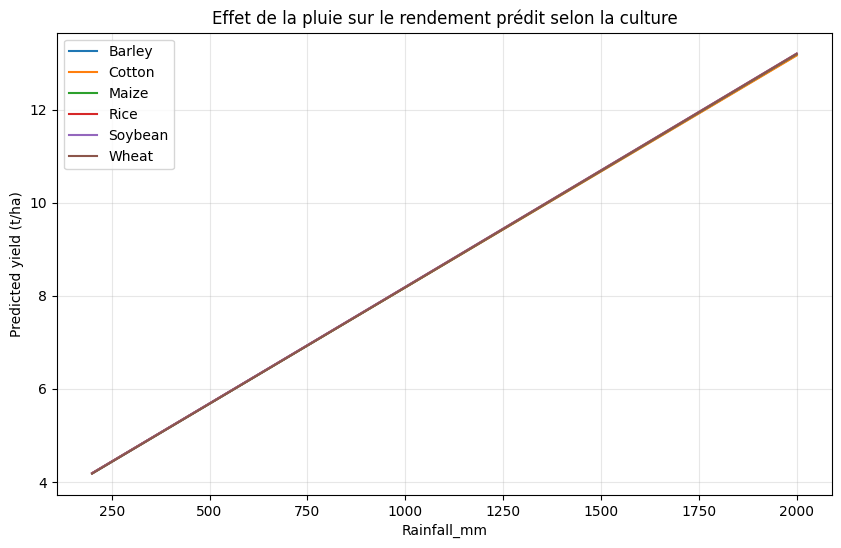

In [16]:
rainfall_grid = np.linspace(200, 2000, 40)

scenario_rows = []
for crop_name in sorted(crop_aux_enriched["Crop"].dropna().astype(str).unique()):
    crop_profile = crop_profiles.loc[crop_profiles["Crop"] == crop_name].head(1)
    if crop_profile.empty:
        continue

    for rain in rainfall_grid:
        scenario_rows.append({
            "Crop": crop_name,
            "Rainfall_mm": rain,
            "Temperature_Celsius": 24,
            "Fertilizer_Used": True,
            "Irrigation_Used": True,
            "ext_mean_temp_by_crop": float(crop_profile["ext_mean_temp_by_crop"].iloc[0]),
            "ext_mean_rainfall_by_crop": float(crop_profile["ext_mean_rainfall_by_crop"].iloc[0]),
            "ext_mean_pesticides_by_crop": float(crop_profile["ext_mean_pesticides_by_crop"].iloc[0]),
            "ext_n_obs_by_crop": float(crop_profile["ext_n_obs_by_crop"].iloc[0]),
            "rainfall_gap_vs_crop_profile": rain - float(crop_profile["ext_mean_rainfall_by_crop"].iloc[0]),
            "temp_gap_vs_crop_profile": 24 - float(crop_profile["ext_mean_temp_by_crop"].iloc[0]),
        })

scenario_df = pd.DataFrame(scenario_rows)
scenario_preds = ridge_crop_interactions_pipe.predict(scenario_df[crop_enriched_features])

plot_df = scenario_df[["Crop", "Rainfall_mm"]].copy()
plot_df["predicted_yield_t_ha"] = scenario_preds

plt.figure(figsize=(10, 6))
for crop_name, group in plot_df.groupby("Crop"):
    group = group.sort_values("Rainfall_mm")
    plt.plot(group["Rainfall_mm"], group["predicted_yield_t_ha"], label=crop_name)

plt.title("Effet de la pluie sur le rendement prédit selon la culture")
plt.xlabel("Rainfall_mm")
plt.ylabel("Predicted yield (t/ha)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 7. Export des artefacts retenus

Deux artefacts sont conservés :

- `model_1_general` : baseline interne de référence ;
- `model_1_crop` : modèle principal retenu pour l’API.

Le second est exporté à partir de la variante **crop_enriched_interactions**.

In [17]:
final_crop_variant_name = "crop_enriched_interactions"
final_crop_features = crop_enriched_features
final_crop_cv_summary = ridge_crop_interactions_cv
final_crop_pipe = ridge_crop_interactions_pipe

MODEL_1_CROP_PATH = ARTIFACTS_DIR / "model_1_crop.joblib"
MODEL_1_CROP_META_PATH = ARTIFACTS_DIR / "model_1_crop_meta.json"

model_1_crop_meta = {
    "model_name": "Ridge",
    "variant_name": final_crop_variant_name,
    "target_name": target_col,
    "target_unit": "t/ha",
    "feature_names": final_crop_features,
    "training_dataset": "crop_aux_enriched",
    "alpha": float(best_interaction_alpha),
    "reference_metrics": final_crop_cv_summary,
    "error_margin_t_ha": float(final_crop_cv_summary["rmse_mean"]),
    "supported_crops": sorted(crop_aux_enriched["Crop"].dropna().astype(str).unique().tolist()),
    "crop_support_counts": (
        crop_aux_enriched["Crop"]
        .dropna()
        .astype(str)
        .value_counts()
        .sort_index()
        .to_dict()
    ),
    "interaction_only": True,
    "interaction_degree": 2,
    "selection_rationale": (
        "Variante retenue pour l'API car elle combine la culture, les variables enrichies "
        "et des interactions explicites, avec un compromis favorable entre performance, "
        "discrimination des cultures et simplicité de déploiement."
    ),
    "preprocessing_note": (
        "Pipeline avec ColumnTransformer, encodage des variables catégorielles, "
        "standardisation des variables numériques et PolynomialFeatures(interaction_only=True, degree=2)."
    ),
}

export_model_with_meta(
    pipe=final_crop_pipe,
    X_ref=X_crop_enriched_full,
    y_ref=y_crop_full,
    meta=model_1_crop_meta,
    model_path=MODEL_1_CROP_PATH,
    meta_path=MODEL_1_CROP_META_PATH,
    run_name="export_model_1_crop",
)

print("Artefacts exportés :", MODEL_1_CROP_PATH.name, MODEL_1_CROP_META_PATH.name)

2026/04/01 00:19:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/01 00:19:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/01 00:19:57 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Artefacts exportés : model_1_crop.joblib model_1_crop_meta.json


## 8. Conclusion opérationnelle

### Modèles conservés
- **`model_1_general`** : baseline générale, utile comme référence interne ;
- **`model_1_crop`** : modèle principal retenu pour l’application.

### Choix retenu pour l’API
La variante **`crop_enriched_interactions`** est conservée comme modèle 1 principal.

### Intérêt du benchmark léger
Le benchmark sur échantillon permet désormais de documenter la démarche de sélection sans conserver l’ancien notebook de baseline dans le parcours principal.

### Étape suivante
La suite du travail s’appuie sur :
- `model_1_crop.*` pour les prédictions principales ;
- `model_1_general.*` comme baseline de comparaison et solution de repli méthodologique.